In [ ]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: la probabilidad de tomar el valor 1 en cada paso. Un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

In [22]:
def simular_PAS(p, n, reps=1):
  # Input:
  # p: probabilidad de que un paso valga +1.
  # n: número de pasos de cada trayectoria.
  # reps: número de trayectorias a simular.
  #
  # Output:
  # Array de NumPy de dimensiones (reps, n). Cada fila contiene una trayectoria
  # simulada y cada columna corresponde al valor del paseo en ese instante.

  # Generamos los pasos aleatorios: +1 con probabilidad p y -1 con probabilidad 1-p.
  pasos = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

  # Calculamos la suma acumulada por filas para obtener la trayectoria del paseo.
  pas = np.cumsum(pasos, axis=1)

  return pas

Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ( p=0.5 ), 17 ( p=0.6 ) y 18 ( p=0.4 ) del tema 1.

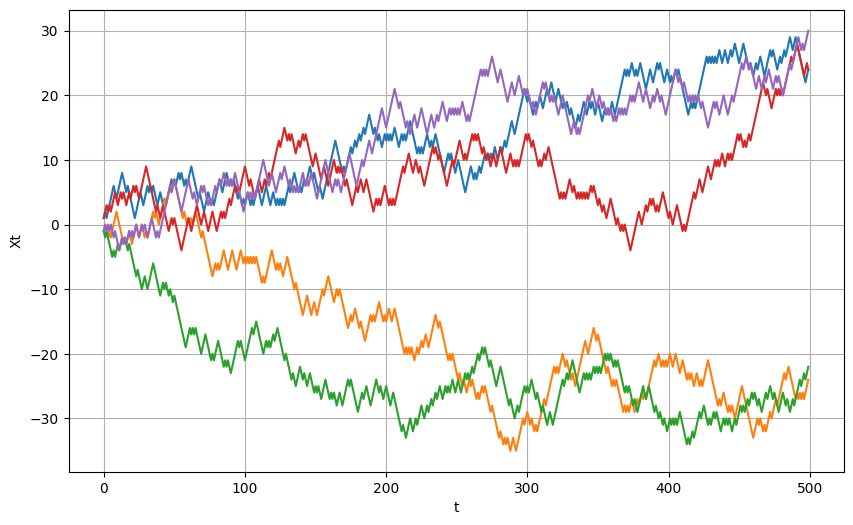

In [25]:
ejemplo_pas = simular_PAS(0.5, 500, 5)
plt.figure(figsize=(10, 6))
for i in range(ejemplo_pas.shape[0]):
    plt.plot(ejemplo_pas[i])

plt.xlabel('t')
plt.ylabel('Xt')
plt.grid(True)

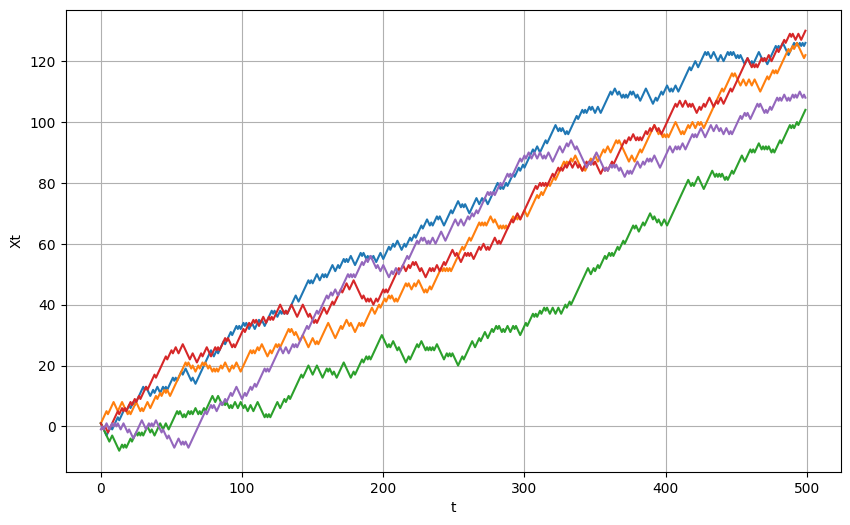

In [26]:
ejemplo_pas = simular_PAS(0.6, 500, 5)
plt.figure(figsize=(10, 6))
for i in range(ejemplo_pas.shape[0]):
    plt.plot(ejemplo_pas[i])

plt.xlabel('t')
plt.ylabel('Xt')
plt.grid(True)

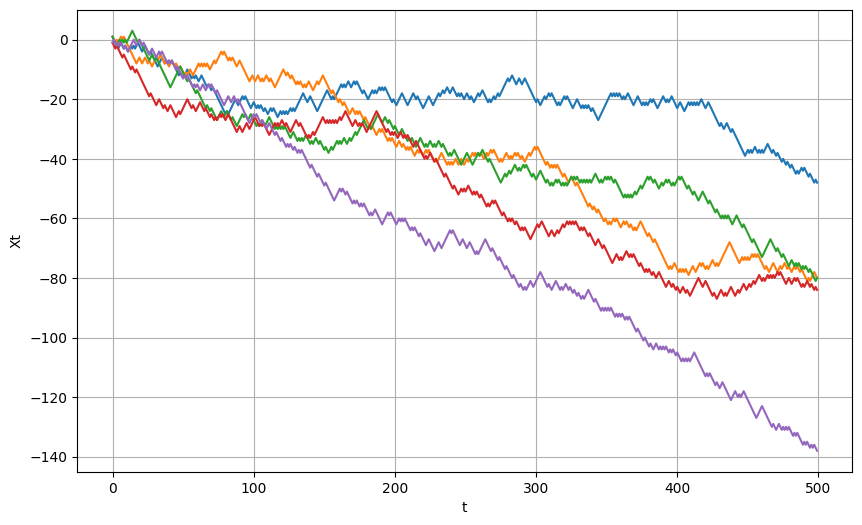

In [27]:
ejemplo_pas = simular_PAS(0.4, 500, 5)
plt.figure(figsize=(10, 6))
for i in range(ejemplo_pas.shape[0]):
    plt.plot(ejemplo_pas[i])

plt.xlabel('t')
plt.ylabel('Xt')
plt.grid(True)

Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)


Escribir código para crear las imágenes de las diapositivas 30 ( p=0.5 ), 31 ( p=0.75 ), 32 ( p=0.95 ) del tema 1.

In [51]:
def representar_PAS(p_val, n=500, reps=20):
    ejemplo_pas = simular_PAS(p_val, n, reps)

    # Añadir una columna de ceros para que comience en el (0,0)
    #ejemplo_pas = np.hstack((np.zeros((ejemplo_pas.shape[0], 1), dtype=int), ejemplo_pas))

    plt.figure(figsize=(12, 7))

    # Número de pasos de 0 a n
    pasos = np.arange(0, n)

    # Dibujar trayectorias simuladas
    for i in range(ejemplo_pas.shape[0]):
        plt.plot(pasos,ejemplo_pas[i])

    # Media teórica: E[X_n] = (2p - 1)n
    media = (2 * p_val - 1) * pasos

    # Desviación típica teórica: sqrt(Var[X_n]) = sqrt(4p(1-p)n)
    desviacion = np.sqrt(4 * p_val * (1 - p_val) * pasos)

    # Sombreado ±2
    plt.fill_between(
        pasos,
        media - 2 * desviacion,
        media + 2 * desviacion,
        color='gray',
        alpha=0.15,
        label=r'$\pm 2\sigma$'
    )

    # Sombreado ±1
    plt.fill_between(
        pasos,
        media - desviacion,
        media + desviacion,
        color='gray',
        alpha=0.3,
        label=r'$\pm 1\sigma$'
    )

    # Media teórica
    plt.plot(
        pasos,
        media,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Media teórica'
    )


    plt.xlabel('t')
    plt.ylabel(r'$X_t$')
    plt.grid(True)
    plt.legend(loc='upper left')

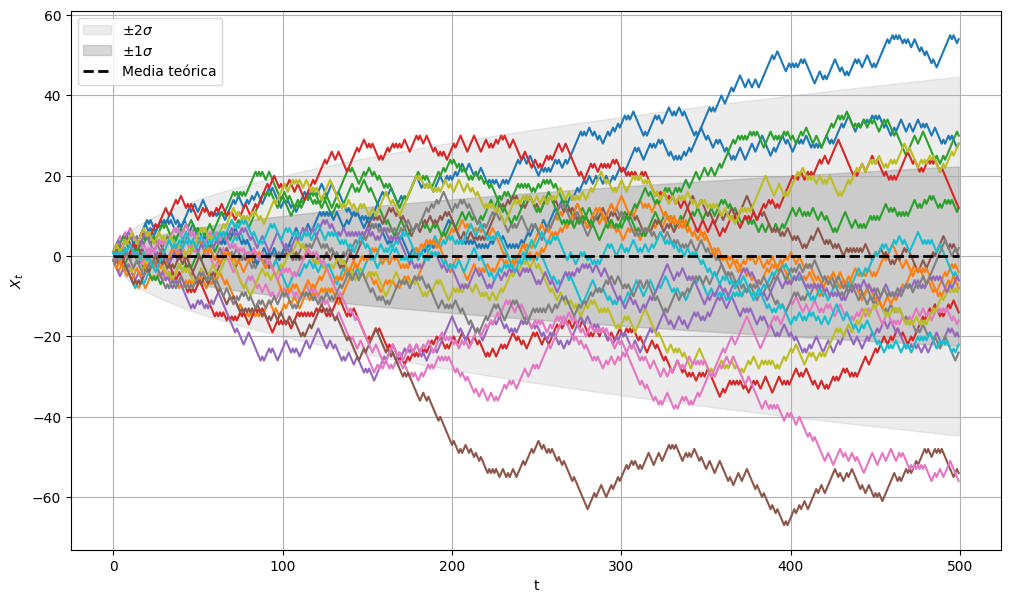

In [53]:
representar_PAS(0.5)

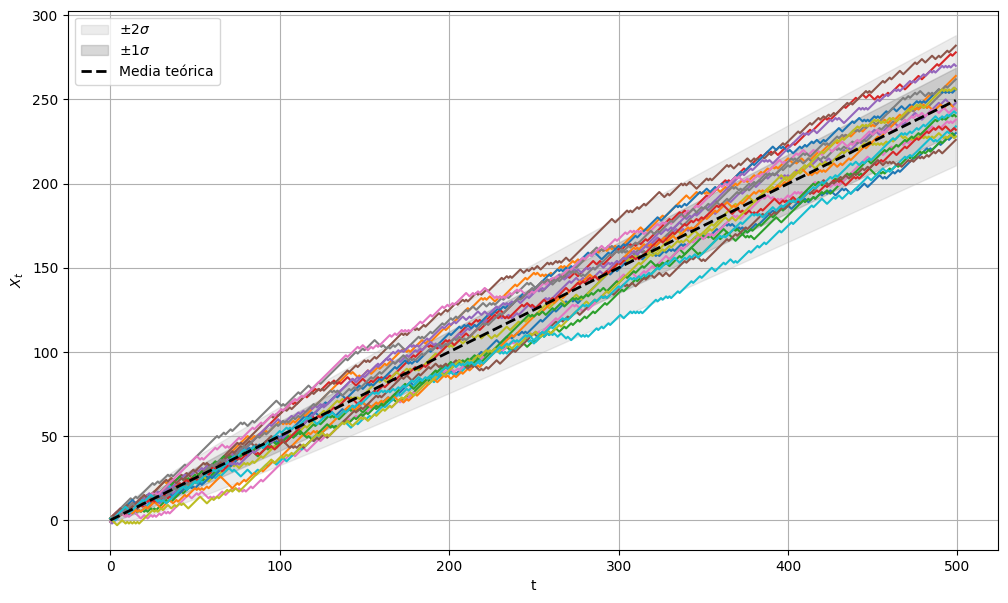

In [54]:
representar_PAS(0.75)

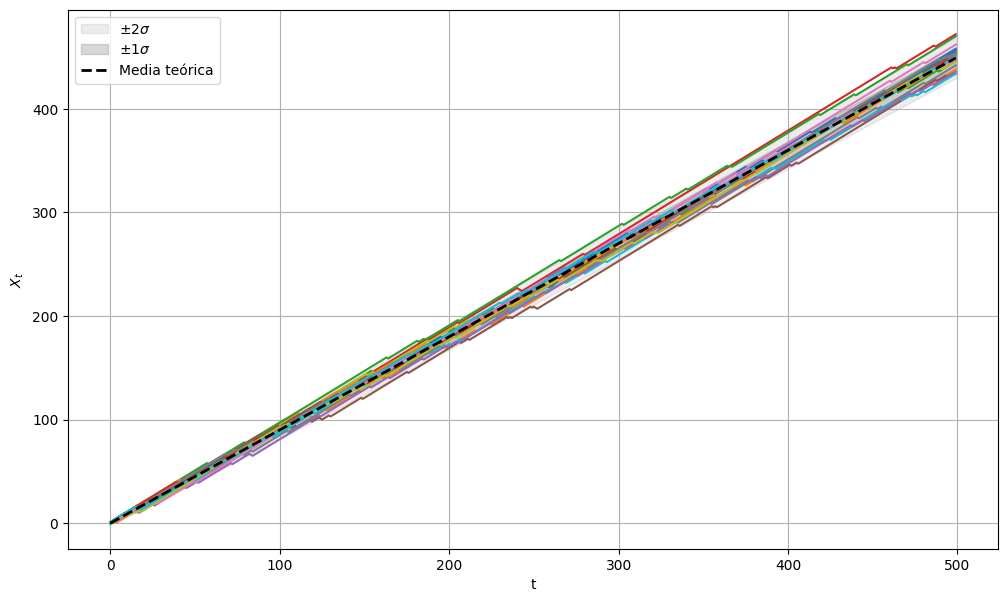

In [55]:
representar_PAS(0.95)

Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

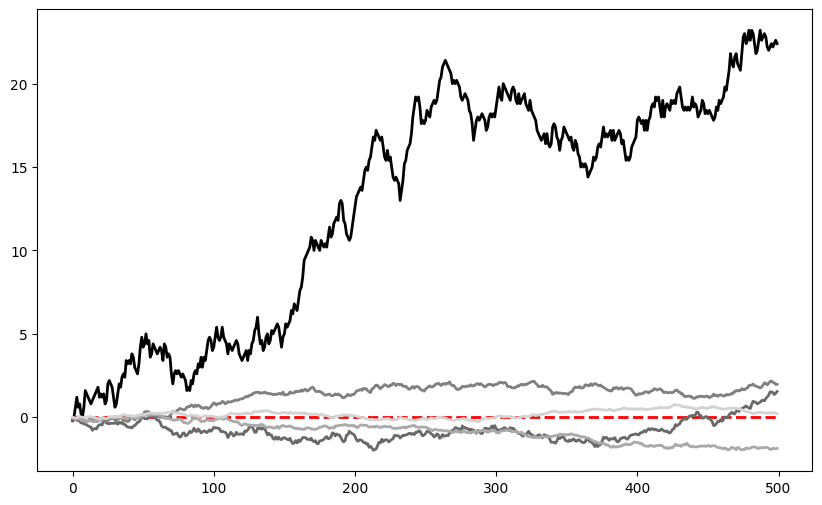

In [57]:
p_val=0.5
t1 = simular_PAS(p_val,500,5)
t2 = simular_PAS(p_val,500,100)
t3 = simular_PAS(p_val,500,200)
t4 = simular_PAS(p_val,500,500)
t5 = simular_PAS(p_val,500,1000)

# Número de pasos de 0 a n
pasos = np.arange(0, 500)

# Media teórica: E[X_t] = (2p - 1)t
media_teo = (2 * p_val - 1) * pasos

plt.figure(figsize=(10, 6))

# Media teórica
plt.plot(
    pasos,
    media_teo,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Media teórica'
)

media1 = np.mean(t1, axis=0)
media2 = np.mean(t2, axis=0)
media3 = np.mean(t3, axis=0)
media4 = np.mean(t4, axis=0)
media5 = np.mean(t5, axis=0)


# Medias empíricas
plt.plot(pasos, media1, color='black', linewidth=2, label='5')
plt.plot(pasos, media2, color='dimgray', linewidth=2, label='100')
plt.plot(pasos, media3, color='gray', linewidth=2, label='200')
plt.plot(pasos, media4, color='darkgray', linewidth=2, label='500')
plt.plot(pasos, media5, color='lightgray', linewidth=2, label='1000')